# Geostrophic adjustment
**20 April 2025 by MiniUFO**

---
[TOC]

---

## 1. Introduction

**Geostrophic adjustment** is a classical problem that was considered almost a century ago by C. G. Rossby ([1937](https://peabody.yale.edu/sites/default/files/documents/), [1938](http://users.uoa.gr/~pjioannou/historical/Rossby-1938.pdf)).  It focuses on a given flow field and a mass field, which is initially not in geostrophic balance, through adjustment, eventually become geostrophically balanced.

This problem is interesting in that:
- it is in **sharp contrast** to the case when there is no rotation;
- it has analytical solution under certain assumptions (during that time scientists did not have computers for numerical ones);
- it ignores the intermediate states during adjustment, and comes straight to **find the final balanced state**;
- it quantifies which, **the flow field** or **the mass field**, adjust more significantly than the other.

Here we use numerical way to get the solution, through `xinvert`, as the problem is a special kind of the steady-state problem.  Some assumptions required for analytical solution can be relaxed.

---

## 2. Theory
### 2.1 The Rossby problem
According to the [note by Mankin Mak](https://www.atmos.illinois.edu/~m-mak/Adjustment-chapter), there are two kinds of adjustment problems.  The first one is called Rossby problem, in which the initial free surface $h(y)=h_0$ is flat.  A zonal flow is prescribed in the center of the domain.  As a result of the imbalance between the mass and flow field, adjustment of them will starts.  Finally, a balanced free surface will be reached, as shown by the black solid line in panel (a).

![schematic2.png](../../../pics/adjustment.png)

### 2.2 The complimentary Rossby problem
The second problem is somewhat different from the first one in the initial state, which is known as the complimentary Rossby problem.  In this second case, a step like free surface is given initially without any flows (similar to the dam break problem).  Then the available potential energy starts to be converted into kinetic energy, which eventually forms a zonal flow that balancing the sloping free surface.

### 2.3 The equations
This is fundamentally a shallow-water case across a range of latitudes over the meridinal direction, with state variables $h$, $u$, and $v$ respectively the free surface height, zonal velocity and meridional velocity.  Zonal variation $\partial_x=0$ is not considered for simplicity.  Initially, $h_0$ and $u_0$ are prescribed, whereas $v_0=0$ is assumed and further simplifies the problem.  At final state, we have geostrophic balance relation between $h_b$ and $u_b$, which are our current target.

Two unknowns $h_b$ and $u_b$ with only one geostrophic relation is not enough for inverting them.  **Another constraint is the conservation of potential vorticity (PV) between initial and final stages for each grid point**.  With the definition of PV $q = (f-\partial_y u)/h$, we have the following two equations with two unknowns:

$$
\begin{align}
fu_b &= -g\frac{\partial h_b}{a\partial \phi} \tag{1}\\
\left[f - \frac{1}{\cos\phi}\frac{\partial }{a\partial \phi}\left(u_0\cos\phi\right)\right]h_0^{-1} &=  \left[f - \frac{1}{\cos\phi}\frac{\partial }{a\partial \phi}\left(u_b\cos\phi\right)\right]h_b^{-1} \tag{2}
\end{align}
$$

By eliminating an unknown of $u_b$, one would get the following equation about $h_b$:

$$
\begin{align}
\frac{\partial}{a\partial \phi}\left(\frac{\cos\phi}{f}\frac{\partial h_b}{a\partial \phi}\right)-\frac{q_0\cos\phi}{g}h_b=-\frac{f\cos\phi}{g} \tag{3}
\end{align}
$$

where $q_0$ is the initial PV.  This is a [screened Poisson equation](https://en.wikipedia.org/wiki/Screened_Poisson_equation), which can be solved numerically using [Successive over-relaxation (SOR)](https://en.wikipedia.org/wiki/Successive_over-relaxation) method, with proper boundary conditions.  Here we demonstrate Rossby's classical examples using [xinvert](https://github.com/miniufo/xinvert).

---

## 3. Calculation
### 3.1 The Rossby problem
First, we define the relavent parameters and prescribe the initial conditions for $u$ and $h$.

In [21]:
import xarray as xr
import numpy as np
import sys
sys.path.append('../../../')
from xinvert import invert_GeoAdjustment

O     = 7.292e-5          # earth rotation rate
g     = 0.1               # (reduced) gravity
yc    = 2001              # grid points in the meridional
H     = 1500              # mean depth of the fluid
lat0  = -50               # center latitude of the jet
deg2m = 6371200/180*np.pi # degree to meter
Rwidth= 0.3               # half width of the jet (degree)

ydef = np.linspace(-58.0, -42, yc) # Southern Ocean
ydef = xr.DataArray(ydef, dims='lat', coords={'lat':ydef})

f    = 2.0 * O * np.sin(np.deg2rad(ydef))
cos  = np.cos(np.deg2rad(ydef))

def geostrophicU(h):
    return -((g*h).differentiate('lat') / deg2m / f)

def PV(u, h):
    return (f - (u*cos).differentiate('lat') / deg2m / cos) / h

def get_ICs(u, h):
    ho  = (ydef - ydef) + h # flat free surface initially
    uo  = ho - ho #+ u * np.exp(-(ydef-lat0)**2/Rwidth**2) # a finite width zonal jet
    uo[int(yc/2)-50:int(yc/2)+50] = u
    PVo = PV(uo, ho)
    
    return ho, uo, PVo

ho1, uo1, PVo1 = get_ICs( 0, H)
ho2, uo2, PVo2 = get_ICs( 1, H)
ho3, uo3, PVo3 = get_ICs( 2, H)
ho4, uo4, PVo4 = get_ICs( 3, H)

a = Rwidth * 111100 * 3
print(f'lambda = {(f*a/np.sqrt(g*H)).mean().values}, R1 = {(3/f/a).mean().values}')

lambda = -0.9091344136182336, R1 = -0.2706907787319999


Then we perform the inversion using `xinvert`.

In [22]:
# invert for the balanced free surface h
iParams = {
    'BCs'      : ['fixed'],
    'mxLoop'   : 500000,
    'tolerance': -1e-19,
    'optArg'   : 1.99,
    'undef'    : -9999,
}

mParams = {'g':g}

h1 = invert_GeoAdjustment(PVo1, dims=['lat'], coords='lat', iParams=iParams, mParams=mParams, icbc=ho1)
h2 = invert_GeoAdjustment(PVo2, dims=['lat'], coords='lat', iParams=iParams, mParams=mParams, icbc=ho2)
h3 = invert_GeoAdjustment(PVo3, dims=['lat'], coords='lat', iParams=iParams, mParams=mParams, icbc=ho3)
h4 = invert_GeoAdjustment(PVo4, dims=['lat'], coords='lat', iParams=iParams, mParams=mParams, icbc=ho4)

u1 = geostrophicU(h1); q1 = PV(u1, h1)
u2 = geostrophicU(h2); q2 = PV(u2, h2)
u3 = geostrophicU(h3); q3 = PV(u3, h3)
u4 = geostrophicU(h4); q4 = PV(u4, h4)

{} loops 500000 and tolerance is 3.789561e-15
{} loops 500000 and tolerance is 0.000000e+00
{} loops 500000 and tolerance is 0.000000e+00
{} loops 500000 and tolerance is 0.000000e+00


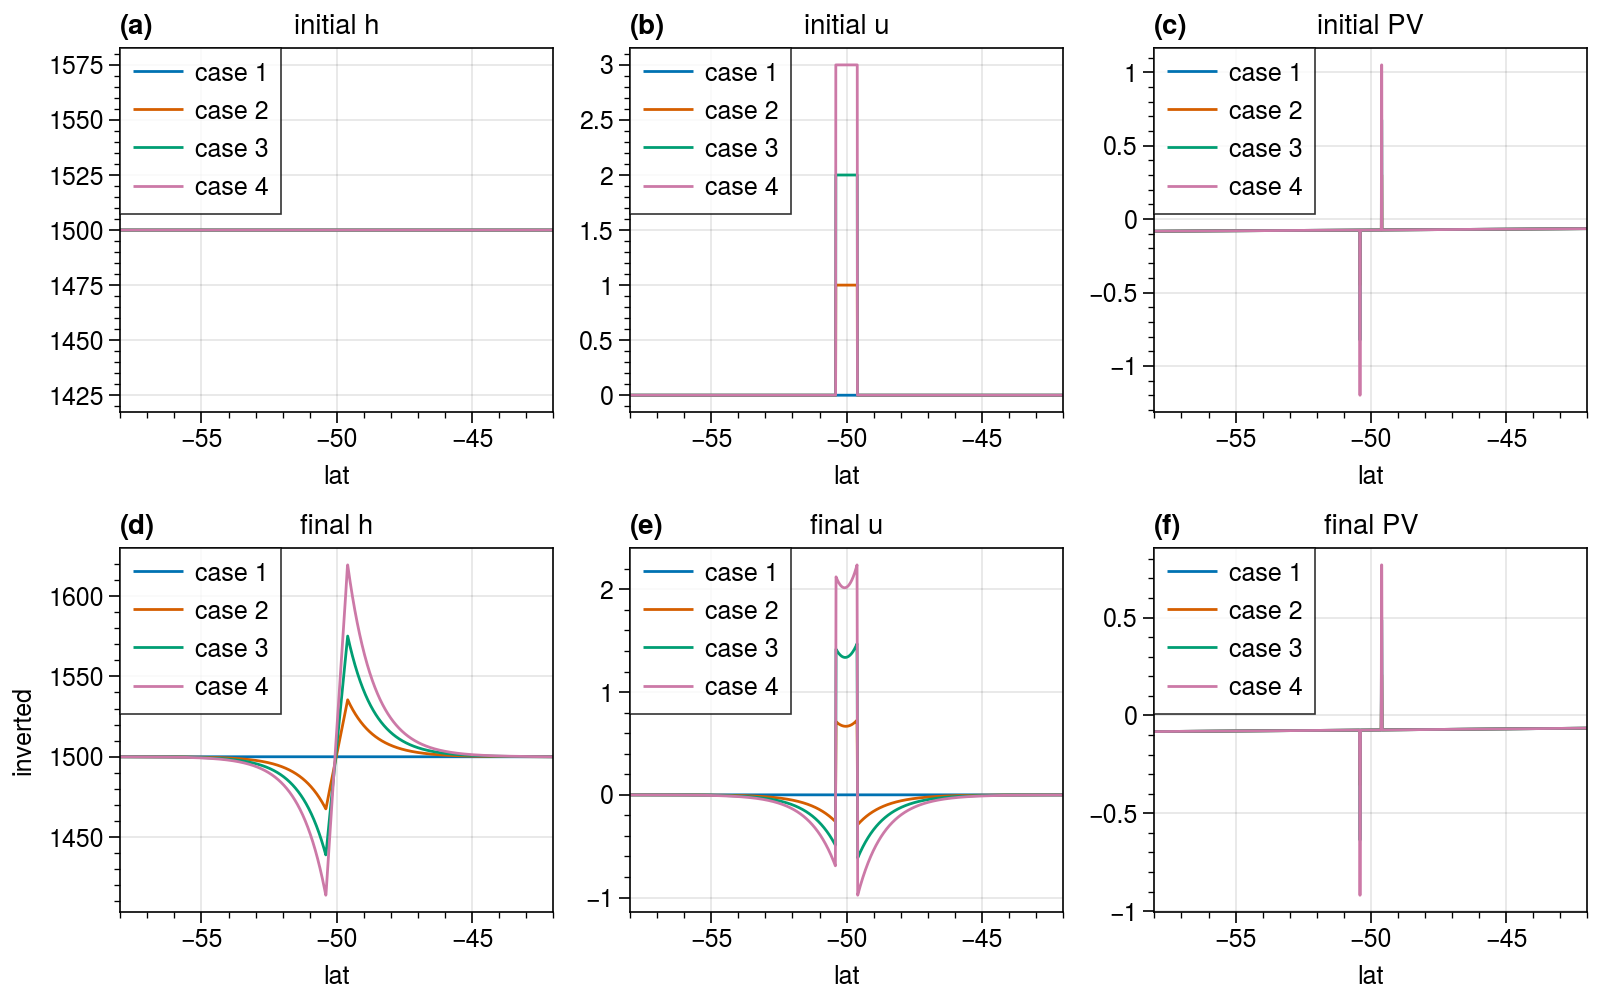

In [23]:
import ultraplot as uplt

def panel(ax, vs, title):
    ms = [ax.plot(v, label=f'case {i+1}', lw=1) for i, v in enumerate(vs)]
    ax.legend(ms, loc='ul', ncols=1)
    ax.set_title(title)
    return ax

fig, axes = uplt.subplots(ncols=3, nrows=2, figsize=(8, 5), facecolor='w', sharex=0, sharey=0)
fig.set_facecolor('w')
panel(axes[0,0], [ho1, ho2, ho3, ho4], 'initial h')
panel(axes[0,1], [uo1, uo2, uo3, uo4], 'initial u')
panel(axes[0,2], [PVo1*1e6, PVo2*1e6, PVo3*1e6, PVo4*1e6], 'initial PV')
panel(axes[1,0], [h1, h2, h3, h4], 'final h')
panel(axes[1,1], [u1, u2, u3, u4], 'final u')
panel(axes[1,2], [q1*1e6, q2*1e6, q3*1e6, q4*1e6], 'final PV')
axes.format(abc='(a)')

After adjustment, the westerly zonal jet will decrease slightly, and generate easterly on the two edges of the jet core.  Note that the asymmetric structure about the meridional center of the jet is clear, as the full variations of Coriolis parameter and water depth.  This is different from linearized dynamics on an $f$ plane.  **PV remains unchanged during the adjustment**.  A physical explanation is that **the adjustment is a fast process** (a timescale for inertial-gravity wave to propagate away), and this will not change PV significantly.

### 3.2 The complimentary Rossby problem

In [4]:
import xarray as xr
import numpy as np
import sys
sys.path.append('../../../')
from xinvert import invert_GeoAdjustment

O     = 7.292e-5          # earth rotation rate
g     = 0.1               # (reduced) gravity
yc    = 2001              # grid points in the meridional
H     = 1500              # mean depth of the fluid
lat0  = -50               # center latitude of the jet
deg2m = 6371200/180*np.pi # degree to meter

ydef = np.linspace(-58.0, -42, yc) # Southern Ocean
ydef = xr.DataArray(ydef, dims='lat', coords={'lat':ydef})

f    = 2.0 * O * np.sin(np.deg2rad(ydef))
cos  = np.cos(np.deg2rad(ydef))

def geostrophicU(h):
    return -((g*h).differentiate('lat') / deg2m / f)

def PV(u, h):
    return (f - (u*cos).differentiate('lat') / deg2m / cos) / h

def get_ICs(h_lower, dh):
    ho = (ydef - ydef) + h_lower
    ho[int(yc/2):] = h_lower + dh
    uo  = ho - ho
    PVo = f / ho
    
    return ho, uo, PVo

ho1, uo1, PVo1 = get_ICs( 10, 30)
ho2, uo2, PVo2 = get_ICs( 20, 40)
ho3, uo3, PVo3 = get_ICs( 30, 50)
ho4, uo4, PVo4 = get_ICs( 40, 60)

In [5]:
# invert for the balanced free surface h
iParams = {
    'BCs'      : ['extend'],
    'mxLoop'   : 500000,
    'tolerance': -1e-19,
    'optArg'   : 1.99,
    'undef'    : -9999,
}

mParams = {'g':g}

h1 = invert_GeoAdjustment(PVo1, dims=['lat'], coords='lat', iParams=iParams, mParams=mParams, icbc=ho1)
h2 = invert_GeoAdjustment(PVo2, dims=['lat'], coords='lat', iParams=iParams, mParams=mParams, icbc=ho2)
h3 = invert_GeoAdjustment(PVo3, dims=['lat'], coords='lat', iParams=iParams, mParams=mParams, icbc=ho3)
h4 = invert_GeoAdjustment(PVo4, dims=['lat'], coords='lat', iParams=iParams, mParams=mParams, icbc=ho4)

u1 = geostrophicU(h1); q1 = PV(u1, h1)
u2 = geostrophicU(h2); q2 = PV(u2, h2)
u3 = geostrophicU(h3); q3 = PV(u3, h3)
u4 = geostrophicU(h4); q4 = PV(u4, h4)

{} loops 500000 and tolerance is 1.429270e-16
{} loops 500000 and tolerance is 1.785189e-16
{} loops 500000 and tolerance is 0.000000e+00
{} loops 500000 and tolerance is 0.000000e+00


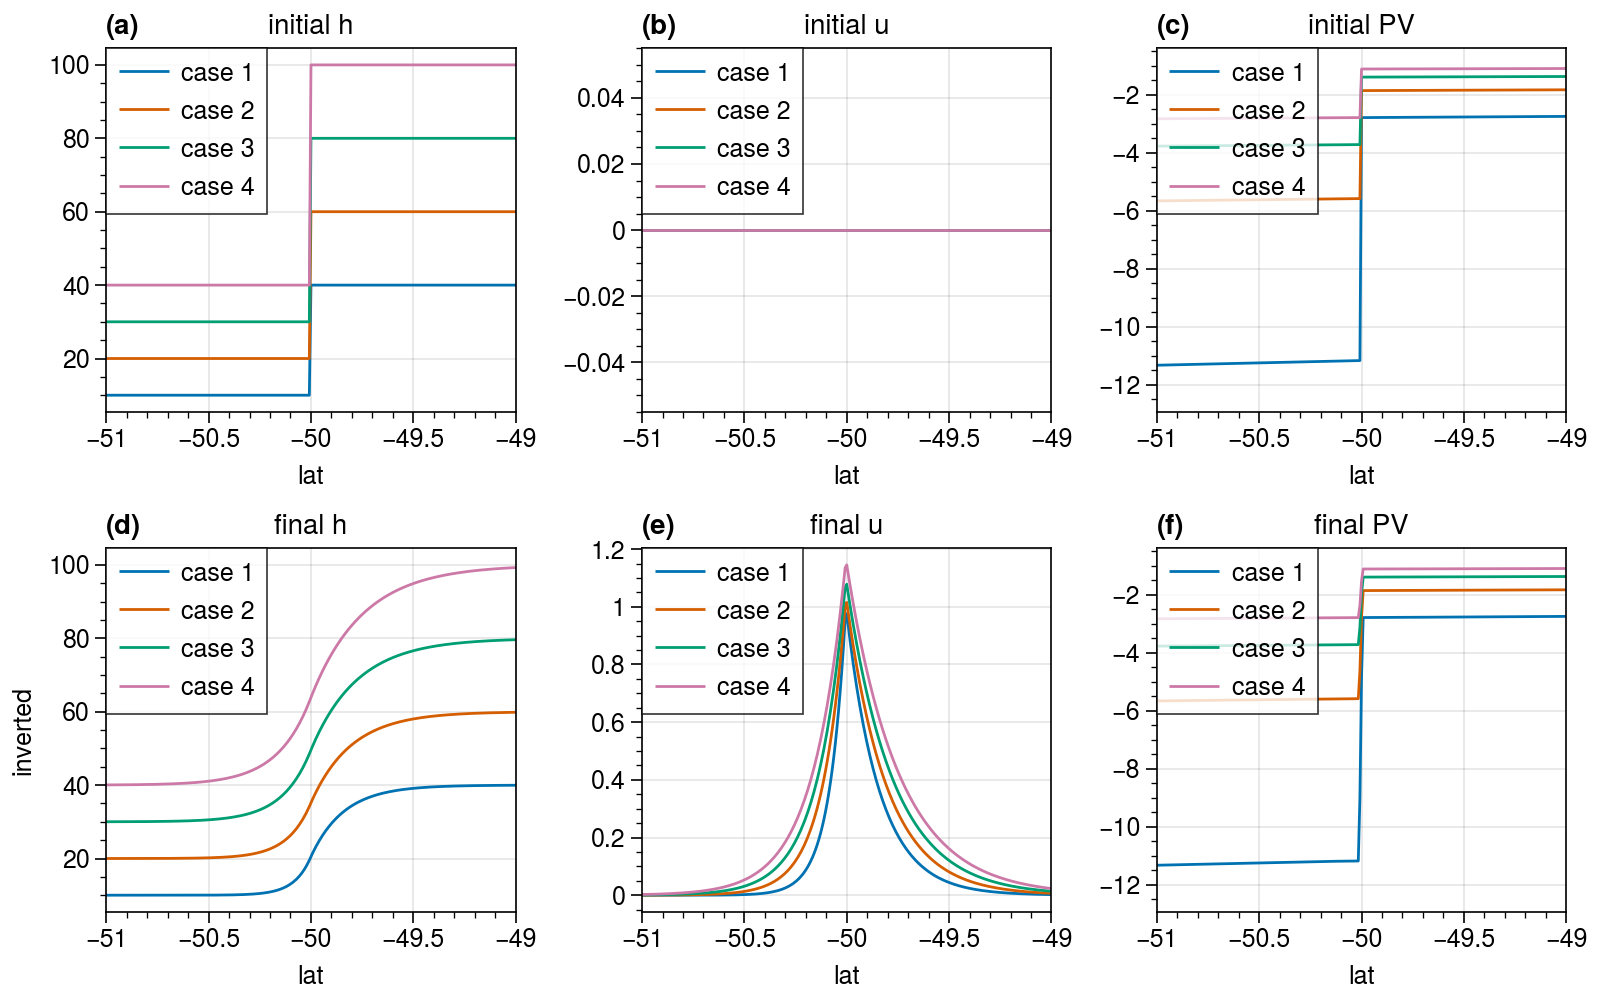

In [13]:
import ultraplot as uplt

def panel(ax, vs, title):
    ms = [ax.plot(v, label=f'case {i+1}', lw=1) for i, v in enumerate(vs)]
    ax.legend(ms, loc='ul', ncols=1)
    ax.set_title(title)
    ax.set_xlim([-51, -49])
    return ax

fig, axes = uplt.subplots(ncols=3, nrows=2, figsize=(8, 5), facecolor='w', sharex=0, sharey=0)
fig.set_facecolor('w')
panel(axes[0,0], [ho1, ho2, ho3, ho4], 'initial h')
panel(axes[0,1], [uo1, uo2, uo3, uo4], 'initial u')
panel(axes[0,2], [PVo1*1e6, PVo2*1e6, PVo3*1e6, PVo4*1e6], 'initial PV')
panel(axes[1,0], [h1, h2, h3, h4], 'final h')
panel(axes[1,1], [u1, u2, u3, u4], 'final u')
panel(axes[1,2], [q1*1e6, q2*1e6, q3*1e6, q4*1e6], 'final PV')
axes.format(abc='(a)')

After adjustment, the step-like non-continuous free surface becomes a smoothed one, holding the PV a step function.  The zonal jet is developed with a clear asymmetric structure.  Note that the asymmetric structure about the meridional center of the jet is clear, as the full variations of Coriolis parameter and water depth.  This is different from linearized dynamics on an $f$ plane.  **The width of the jet stream is not the same on the northern and southern edge of the jet core**, because the deformation radii $L_d=\sqrt{gH}/f$ are not the same.

---

### References
1. Rossby, C. G., 1937: [On the mutual adjustment of pressure and velocity distributions in certain simple current systems.](https://peabody.yale.edu/sites/default/files/documents/publications/jmr01-01-03CGROSSBY-1.pdf) *J. Mar. Res.*, **1**, 15-28.
2. Rossby, C. G.,1938: [On the mutual adjustment of pressure and velocity distributions in certain simple current systems II.](http://users.uoa.gr/~pjioannou/historical/Rossby-1938.pdf) *J. Mar. Res.*, **1**, 239–263.

